# Hotel Booking Cancellation – Preprocessing and Train/Test Split

This notebook takes the clean table from `01_eda_cleaning.ipynb`, decides which columns go into the models and how they will be encoded, and splits the data into a training set and a test set. All four model notebooks load the same two files, so every model is compared on exactly the same rows.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

## 1. Load the clean data

In [2]:
df = pd.read_csv('../data/processed/hotel_bookings_clean.csv')
print(df.shape)
df.head()

(84969, 28)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,deposit_type,agent,customer_type,adr,total_of_special_requests,total_nights,total_guests,is_family
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,C,No Deposit,0,Transient,0.0,0,0,2,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,C,No Deposit,0,Transient,0.0,0,0,2,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,A,No Deposit,0,Transient,75.0,0,1,1,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,A,No Deposit,304,Transient,75.0,0,1,1,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,A,No Deposit,240,Transient,98.0,1,2,2,0


In [3]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
deposit_type                          str
agent                               int64
customer_type                         str
adr                               

## 2. Features and target

In [4]:
# arrival_date_year: does each year cover the same months?
df.groupby('arrival_date_year').agg(bookings=('is_canceled', 'size'),
                                    months=('arrival_date_month', 'nunique'),
                                    cancel_rate=('is_canceled', 'mean')).round(3)

,bookings,months,cancel_rate
arrival_date_year,,,
2015,12597,6,0.208
2016,41269,12,0.266
2017,31103,8,0.321


2015 only has 6 months of arrivals and 2017 only 8, so the rising cancellation rate by year (20.8% → 26.6% → 32.1%) partly reflects which months each year contains. A model used on new bookings would also only ever see years it was never trained on. `arrival_date_year` is dropped; seasonality is still covered by the month, week and day columns.

In [5]:
# arrival_date_week_number: does it add anything the month does not already say?
month_number = pd.to_datetime(df['arrival_date_month'], format='%B').dt.month
print('correlation of week number with month number:', round(df['arrival_date_week_number'].corr(month_number), 3))

correlation of week number with month number: 0.995


Week number and month carry the same information (correlation 0.995). Kept together, a linear model gives both large coefficients with opposite signs that cancel out, so neither can be read. `arrival_date_week_number` is dropped; month plus day of month still place the arrival within the year.

In [6]:
# the target is is_canceled; arrival_date_year and arrival_date_week_number are dropped for the reasons above
X = df.drop(columns=['is_canceled', 'arrival_date_year', 'arrival_date_week_number'])
y = df['is_canceled']

# agent is an ID, not a quantity (agent 240 is not "bigger" than agent 9), so treat it as a category
X['agent'] = X['agent'].astype(str)

categorical_cols = X.select_dtypes(exclude='number').columns.tolist()
numeric_cols = X.select_dtypes(include='number').columns.tolist()
print('categorical:', len(categorical_cols), categorical_cols)
print('numeric:    ', len(numeric_cols), numeric_cols)

categorical: 10 ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type']
numeric:     15 ['lead_time', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'total_of_special_requests', 'total_nights', 'total_guests', 'is_family']


In [7]:
X[categorical_cols].nunique().sort_values()

hotel                     2
deposit_type              3
meal                      4
customer_type             4
distribution_channel      5
market_segment            8
reserved_room_type        9
arrival_date_month       12
country                 178
agent                   334
dtype: int64

## 3. Encoding plan

Eight of the ten categorical columns have 12 levels or fewer, so plain one-hot encoding adds only a few columns each. `country` (178 levels) and `agent` (334 levels) are different: one-hot encoding them directly would add over 500 columns, most of them almost always zero.

In [8]:
for col in ['country', 'agent']:
    counts = X[col].value_counts()
    rare = counts[counts < 100]
    print(f'{col}: {len(counts)} levels, {len(rare)} with fewer than 100 bookings, '
          f'covering {rare.sum()} rows ({rare.sum() / len(X):.1%})')
    print(counts.head(10).to_dict(), '\n')

country: 178 levels, 142 with fewer than 100 bookings, covering 2292 rows (2.7%)
{'PRT': 26439, 'GBR': 10144, 'FRA': 8624, 'ESP': 7085, 'DEU': 5221, 'ITA': 2975, 'IRL': 2957, 'BEL': 2055, 'BRA': 1969, 'NLD': 1881} 

agent: 334 levels, 277 with fewer than 100 bookings, covering 4278 rows (5.0%)
{'9': 28473, '240': 12880, '0': 11587, '14': 3316, '7': 3273, '250': 2761, '241': 1636, '28': 1475, '8': 1366, '1': 1021} 



142 countries and 277 agents have fewer than 100 bookings each, yet together they cover only 2.7% and 5.0% of the rows. The models therefore use `OneHotEncoder(min_frequency=100, handle_unknown='infrequent_if_exist')`: every common level gets its own column, and all rare levels (plus any level first seen in the test set) share one "infrequent" column. This keeps the signal from the big markets without writing a custom encoder.

**One-hot or frequency encoding? Measured, not chosen.** An alternative to one-hot encoding for a
high-cardinality column like `country` is frequency encoding: replace each country with how common it
is, one number instead of a wide block of columns. That is a reasonable idea, so it was run rather
than argued about - `scripts/ablation.py` scores both on the same folds with the same model.

One caveat on that comparison, because it is not quite like-for-like: the frequency arm computes each
country's share over the whole table rather than inside each fold, so it carries a small advantage the
one-hot arm does not (`freq_encode` in `scripts/ablation.py`). It lost anyway, which makes the case
for one-hot stronger rather than weaker - but the number should not be read as a clean head-to-head.

| encoding | CV PR-AUC | |
|---|---|---|
| `OneHotEncoder(min_frequency=100)` | **0.7660** | what this notebook uses |
| frequency encoding | 0.7650 | -0.0010 |

One-hot wins, though by less than the fold-to-fold noise (+/- 0.0071), so the fair reading is that the
two are equivalent here and there is no reason to change. We keep one-hot because it is also the more
readable of the two: `country_PRT` names itself in a feature-importance plot, while a frequency column
does not.

**Why one encoder, fitted once.** A common shortcut is to call `pd.get_dummies` separately on the
training set and the test set and then line the columns up with
`.align(join='left', axis=1, fill_value=0)`. Any category that appears in test but not in train is
silently filled with zeros, and the two column sets are only kept in step by that align - a category
that turns up later is encoded as "none of the above" without anything failing. Fitting one encoder on
the training set and applying it to test makes the same situation explicit rather than silent, which
is what `handle_unknown='infrequent_if_exist'` is for.

**Scaling.** Logistic Regression needs numeric columns on a similar scale (`lead_time` goes up to 737 while `is_family` is 0 or 1), so its pipeline adds a `StandardScaler`. Decision Tree, Random Forest and XGBoost split on thresholds, which scaling does not change, so they use the numbers as they are.

**Nothing is fitted here.** The encoder and the scaler learn from data (which countries are common, the mean and spread of `adr`). If they were fitted on the full table, the test rows would influence them before any model is evaluated. They are built inside each model's `Pipeline` instead, so they are only ever fitted on training data.

## 4. Class balance

In [9]:
y.value_counts(normalize=True).round(4)

is_canceled
0    0.7225
1    0.2775
Name: proportion, dtype: float64

27.7% of bookings are cancelled. That is imbalanced, but not severely - the minority class still has
23,564 examples, which is plenty for every model in this project.

**How the imbalance is handled.** The split is stratified, so both parts carry the same 27.7%.
Class weighting was measured rather than assumed, and it did not help: across the four models it was
tried on, `class_weight='balanced'` (or `scale_pos_weight` for XGBoost) moved PR-AUC by between
-0.0100 and -0.0019 - never once positive. That measurement is kept in `archive/weighted/`.
What does carry the imbalance is the decision threshold: `03`-`07` each choose one from out-of-fold
probabilities instead of accepting 0.50, and that is the larger effect by far.

**On SMOTE.** It is not used here, for two reasons. At 27.7% the minority class is not starved, and
SMOTE invents synthetic bookings that never happened - reweighting the real rows is the more honest
option when the real rows are sufficient. If it is tried later, it must be fitted **inside each
cross-validation fold**, never before the split: oversampling first copies minority rows across the
train/test line and produces exactly the same false gain that duplicate rows produce in `01` section
5. That mistake is common and it is invisible in the score, which is what makes it dangerous.

## 5. Train/test split

In [10]:
# 80/20 split; stratify keeps the same cancellation rate in both parts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('train:', X_train.shape, ' cancel rate:', round(y_train.mean(), 4))
print('test: ', X_test.shape, ' cancel rate:', round(y_test.mean(), 4))
print('cancellations in test:', y_test.sum())

train: (67975, 25)  cancel rate: 0.2775
test:  (16994, 25)  cancel rate: 0.2775
cancellations in test: 4715


The training set has 67,975 bookings, enough for 5-fold cross-validation (about 13,600 rows in each validation fold). The test set keeps 16,994 bookings with 4,715 cancellations, which is enough for stable test scores. Stratification gives both parts the same 27.75% cancellation rate.

### 5.1 Cancellation patterns, on the training set only

The charts in section 6 of `01_eda_cleaning.ipynb` were drawn on all 84,969 rows, which includes the
16,994 test bookings. They are what led to keeping `hotel`, `lead_time`, `deposit_type` and the rest,
so strictly a test outcome was visible while a feature decision was being made.

The effect is small, but it is the same rule the encoder, the scaler and the ranking below already
follow: anything that decides something learns from `X_train`. So the four charts that actually drove
a decision are redrawn here on the 67,975 training rows, with the group sizes shown next to every
rate - `01` prints the percentage alone, and a percentage from 160 bookings is not the same evidence
as one from 50,000.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
palette = ['#2B5C8F', '#E05A47']

# training rows only - X_test is not touched anywhere in this section
train_eda = X_train.assign(is_canceled=y_train)
base_rate = train_eda['is_canceled'].mean()
print(f'training bookings: {len(train_eda):,}   cancellation rate: {base_rate:.2%}')


def rate_table(series, name):
    """Cancellation rate per group with the group size beside it."""
    out = train_eda.groupby(series, observed=True)['is_canceled'].agg(['count', 'mean'])
    out.columns = ['bookings', 'cancel_rate']
    out['cancel_rate'] = (out['cancel_rate'] * 100).round(1)
    out.index.name = name
    return out


def plot_rate(table, title, xlabel=None, figsize=(7, 4)):
    plt.figure(figsize=figsize)
    bars = plt.bar(table.index.astype(str), table['cancel_rate'], color=palette[0])
    plt.bar_label(bars, fmt='%.1f%%', padding=3)
    # the label under each bar is the group size, so a tall thin bar is not misread
    plt.xticks(range(len(table)),
               [f'{i}\n(n={n:,})' for i, n in zip(table.index.astype(str), table['bookings'])],
               rotation=0)
    plt.axhline(base_rate * 100, color=palette[1], linestyle='--', label='training rate')
    plt.ylabel('Cancellation rate (%)')
    if xlabel:
        plt.xlabel(xlabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

training bookings: 67,975   cancellation rate: 27.75%


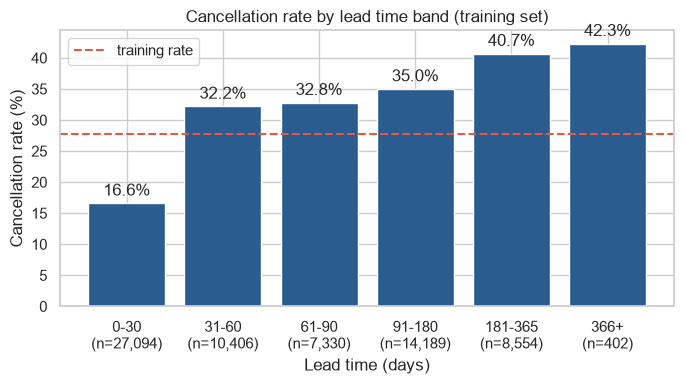

,bookings,cancel_rate
lead_time,,
0-30,27094,16.6
31-60,10406,32.2
61-90,7330,32.8
91-180,14189,35.0
181-365,8554,40.7
366+,402,42.3


In [12]:
lead_band = pd.cut(train_eda['lead_time'], bins=[-1, 30, 60, 90, 180, 365, np.inf],
                   labels=['0-30', '31-60', '61-90', '91-180', '181-365', '366+'])
lead = rate_table(lead_band, 'lead_time')
plot_rate(lead, 'Cancellation rate by lead time band (training set)', 'Lead time (days)')
lead

The rise is monotonic and every band is large enough to trust: even the smallest holds thousands of
bookings. A booking made the week before arrival is a guest with firm plans; one made a year ahead is
a placeholder that costs nothing to abandon. This is the pattern the permutation ranking below scores
near the top, and it survives the move to training-only data unchanged.

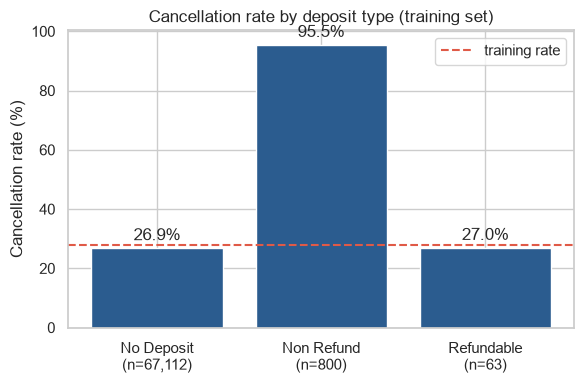

,bookings,cancel_rate
deposit_type,,
No Deposit,67112,26.9
Non Refund,800,95.5
Refundable,63,27.0


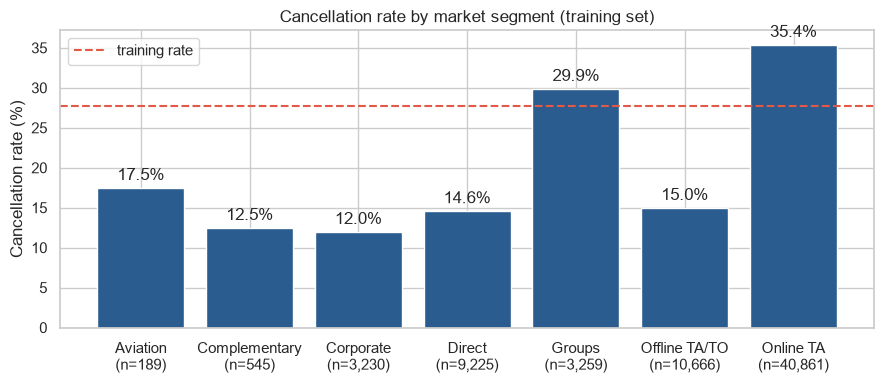

,bookings,cancel_rate
market_segment,,
Aviation,189,17.5
Complementary,545,12.5
Corporate,3230,12.0
Direct,9225,14.6
Groups,3259,29.9
Offline TA/TO,10666,15.0
Online TA,40861,35.4


In [13]:
deposit = rate_table(train_eda['deposit_type'], 'deposit_type')
plot_rate(deposit, 'Cancellation rate by deposit type (training set)', figsize=(6, 4))
display(deposit)

segment = rate_table(train_eda['market_segment'], 'market_segment')
plot_rate(segment, 'Cancellation rate by market segment (training set)', figsize=(9, 4))
segment

**Deposit type is where the counts change the reading.** `Non Refund` cancels almost always, which
looks like the strongest signal in the dataset until the group size is read next to it: it covers well
under 1% of training bookings after deduplication. That is why `scripts/ablation.py` arm 13 finds that
removing `deposit_type` costs only 0.0040 - the column is right about a group too small to move the
score much. `Refundable` is smaller still and its rate should not be read as evidence of anything.

**Market segment is the opposite case.** `Groups` and `Online TA` both sit above the base rate, and
`Online TA` matters because it is large - a few points of extra risk across tens of thousands of
bookings is worth more to the hotel than a near-certain rule covering a few hundred. `Complementary`
and `Aviation` are small enough that their bars are indicative only.

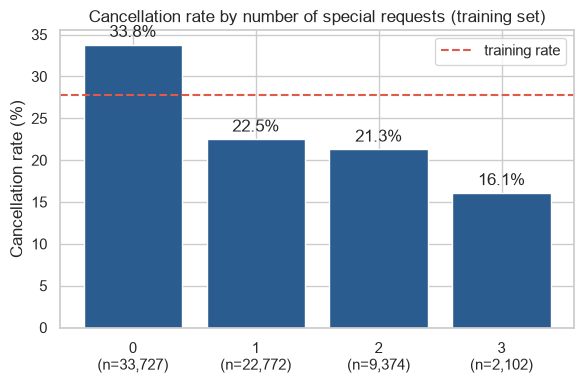

,bookings,cancel_rate
total_of_special_requests (3+ grouped),,
0,33727,33.8
1,22772,22.5
2,9374,21.3
3,2102,16.1


In [14]:
requests = rate_table(train_eda['total_of_special_requests'].clip(upper=3),
                      'total_of_special_requests (3+ grouped)')
plot_rate(requests, 'Cancellation rate by number of special requests (training set)', figsize=(6, 4))
requests

Requests behave like commitment: a guest who has asked for a high floor and a late check-in has
started planning the stay. The rate roughly halves from none to one and then flattens, and it never
reaches zero - guests with requests still cancel. That floor is the difference between this column and
`required_car_parking_spaces`, which `01` drops: parking cuts to *exactly* zero, which is not a
behaviour pattern but a record written at check-in. The argument is set out in section 4.2 of `01`;
the point here is that the gradient holds on training data alone.

#### Do the training-only rates change any conclusion?

The comparison below puts the training rate next to the full-table rate from `01` for every group used
above. If a decision made on the full table was really driven by test rows, a gap would show here.

In [15]:
full = df.assign(lead_band=pd.cut(df['lead_time'], bins=[-1, 30, 60, 90, 180, 365, np.inf],
                                  labels=['0-30', '31-60', '61-90', '91-180', '181-365', '366+']),
                 requests_c=df['total_of_special_requests'].clip(upper=3))

checks = []
for col, train_col in [('lead_band', lead_band),
                       ('deposit_type', train_eda['deposit_type']),
                       ('market_segment', train_eda['market_segment']),
                       ('requests_c', train_eda['total_of_special_requests'].clip(upper=3))]:
    t = train_eda.groupby(train_col, observed=True)['is_canceled'].mean()
    f = full.groupby(col, observed=True)['is_canceled'].mean()
    for level in f.index:
        checks.append({'column': col, 'level': str(level),
                       'full_table_%': round(f[level] * 100, 1),
                       'training_%': round(t.get(level, np.nan) * 100, 1),
                       'difference_pp': round((t.get(level, np.nan) - f[level]) * 100, 2)})

checks = pd.DataFrame(checks)
print('largest absolute difference:', checks['difference_pp'].abs().max(), 'percentage points')
checks

largest absolute difference: 3.25 percentage points


,column,level,full_table_%,training_%,difference_pp
0,lead_band,0-30,16.5,16.6,0.02
1,lead_band,31-60,31.9,32.2,0.29
2,lead_band,61-90,32.9,32.8,-0.04
3,lead_band,91-180,35.3,35.0,-0.27
4,lead_band,181-365,40.8,40.7,-0.09
5,lead_band,366+,42.9,42.3,-0.57
6,deposit_type,No Deposit,27.0,26.9,-0.01
7,deposit_type,Non Refund,94.9,95.5,0.55
8,deposit_type,Refundable,30.2,27.0,-3.25
9,market_segment,Aviation,19.7,17.5,-2.27


**Every large group moves by less than half a percentage point.** `Online TA` (35.3% against 35.4%),
all six lead-time bands and every special-request level are effectively unchanged, so the conclusions
drawn from them in `01` did not depend on having seen the test rows.

The three exceptions prove the point about counts rather than undermining it:

- `Refundable` moves **-3.25 points**, the largest gap in the table, on roughly 160 bookings.
- `Aviation` moves **-2.27 points**, on a similarly small group.
- `Undefined` market segment is **NaN** on training data: all of its rows landed in the test split.

These are the smallest groups in the dataset, and a group small enough to shift three points between
two random halves of the same table is a group too small to build a rule on. The bars with n in the
thousands did not move; the bars with n in the hundreds did.

`Undefined` is also a concrete example of the encoder setting chosen in section 3: a category can be
absent from training and still appear later, which is exactly what `handle_unknown='infrequent_if_exist'`
exists to absorb. Here it happened inside our own split, before any new booking is involved.

Keeping both sets of charts is deliberate. `01` describes the data a reader is meeting for the first
time; this section is the version that is allowed to decide something.

### 5.2 Which features carry the signal

The ranking below is fitted on the **training set only**. That is not a formality: a ranking computed
on all 84,969 rows would have looked at the test set to decide what the model is allowed to see, and
every later test score would be quietly optimistic. The same rule covers the encoder above and the
scaler in `03` - anything that learns from data learns from `X_train`, never from `X_test`.

**Permutation importance, not gain importance.** The obvious choice is XGBoost's built-in
`feature_importances_`, and it gives the wrong answer here. Summed back over one-hot columns it
rewards width: `agent` has 334 levels and `country` 178, so they collect hundreds of small
contributions each and come out on top, while `lead_time` competes as a single column and sinks to
the bottom - contradicting `01`, where lead time is one of the clearest drivers.

Permutation importance asks a fairer question: shuffle one column and see how much the score falls. A
column that the model genuinely relies on hurts when scrambled, however many one-hot pieces it was
split into. It also reports a standard deviation over repeats, so a number that is unstable looks
unstable.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

# fitted on the training rows only - X_test is not touched anywhere in this cell
rank_prep = ColumnTransformer([
    ('num', 'passthrough', numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100), categorical_cols),
], verbose_feature_names_out=False)

rank_pipe = Pipeline([('prep', rank_prep),
                      ('model', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                              random_state=42, n_jobs=-1, eval_metric='logloss'))])

# a held-out slice of the TRAINING set to permute against, so the ranking is not
# measured on the same rows the model just fitted
X_fit, X_perm, y_fit, y_perm = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

rank_pipe.fit(X_fit, y_fit)

perm = permutation_importance(rank_pipe, X_perm, y_perm, n_repeats=5,
                              scoring='average_precision', random_state=42, n_jobs=-1)

importance = (pd.DataFrame({'feature': X_train.columns,
                            'drop_in_pr_auc': perm.importances_mean,
                            'std': perm.importances_std})
              .sort_values('drop_in_pr_auc', ascending=False)
              .reset_index(drop=True))
importance.round(4)

,feature,drop_in_pr_auc,std
0,country,0.1491,0.0013
1,lead_time,0.1280,0.0058
2,agent,0.1096,0.0008
3,total_of_special_requests,0.1066,0.0033
4,previous_cancellations,0.0702,0.0041
5,market_segment,0.0546,0.0012
6,customer_type,0.0439,0.0016
7,deposit_type,0.0394,0.0032
8,previous_bookings_not_canceled,0.0206,0.0006
9,adr,0.0152,0.0015


Read this as "how much PR-AUC the model loses when this column is scrambled".

The change that matters is `lead_time`. Under XGBoost gain importance it ranked near the bottom,
contradicting `01` where it is one of the clearest drivers; under permutation it comes second at
**0.128**. That was the artefact, and it is gone.

`country` (0.149) and `agent` (0.110) still rank at the top, but for a different and better reason
than before. Gain importance put them there because they are wide; permutation puts them there because
scrambling them genuinely costs the model 0.15 and 0.11 PR-AUC. That is a measured loss, not an
artefact of counting columns - and it is the evidence for keeping `country` rather than dropping it
for being awkward.

`total_of_special_requests` comes fourth at 0.107 while `deposit_type` is eighth at 0.039 - the same
ordering the stress tests in `01` section 8 produced by removing each column and refitting from
scratch (-0.0530 against -0.0040). Two different methods, same answer, which is the point of running
both.

The standard deviations are small (0.0006 to 0.0058 across the top ten), so this ordering is stable
rather than a single lucky shuffle.

**Nothing is dropped on the strength of this.** A low score means the model found little use for a
column *given the others*, not that removing it would help; whether a smaller feature set scores
better is a question `scripts/ablation.py` can answer and has not been asked. All 25 features go
through.

## 6. Save the train and test sets

In [17]:
train = X_train.assign(is_canceled=y_train)
test = X_test.assign(is_canceled=y_test)

train.to_csv('../data/processed/train.csv', index=False)
test.to_csv('../data/processed/test.csv', index=False)
print(train.shape, test.shape)

(67975, 26) (16994, 26)


## How the models will be evaluated

- Every model is tuned with **5-fold stratified cross-validation on the training set only**.
- The main score is **PR-AUC** (average precision). With only 27.7% cancellations, accuracy flatters a model that rarely predicts a cancellation, while PR-AUC measures how well the model ranks cancelled bookings above the rest.
- **F1 and recall** on the cancelled class are reported next to it, because a missed cancellation (an empty room) is the costly mistake for the hotel.
- The **test set is used once per model**, after tuning is finished. Note that `agent` must be read back as text (`dtype={'agent': str}`), because a CSV does not store column types.